In [ ]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper
import arxiv

api_wrapper_arxiv = ArxivAPIWrapper(
    top_k_results=2, 
    doc_content_chars_max=500
)
arxiv = ArxivQueryRun(api_wrapper= api_wrapper_arxiv)

arxiv.invoke("Attention is all you need")

# client = arxiv.Client()
# search = arxiv.Search("Attention is all you need")
# result = list(client.results(search))


### Wikipedia Search

In [ ]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
import arxiv

api_wrapper_arxiv = WikipediaAPIWrapper(
    top_k_results=5, 
    # doc_content_chars_max=500
)
wiki = WikipediaQueryRun(api_wrapper= api_wrapper_arxiv)

print(wiki.invoke("what is machine learning"))


### Tavily Search

In [ ]:
import os
from dotenv import load_dotenv
from tavily import TavilyClient
import json

load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

tavily_client = TavilyClient()

response = tavily_client.search(
    query="Lastest AI news for June 12th 20206",
    search_depth="advanced"
)

# print(json.dumps(response, indent=4))

In [ ]:
# for result in response["results"]:
result = response["results"][0]
print(f"""Title: {result["title"]}
Content: {result["content"]}
URL: {result["url"]}
Score: {result["score"]}
=================================================================================
"""
)

### Tools Integration

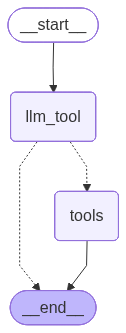

================================ Human Message =================================

What is attention is all you need.
================================== Ai Message ==================================
Tool Calls:
  wikipedia (vd48veanj)
 Call ID: vd48veanj
  Args:
    query: Attention is All You Need
================================= Tool Message =================================
Name: wikipedia

Page: Attention Is All You Need
Summary: "Attention Is All You Need" is a 2017 research paper in machine learning authored by eight scientists and engineers working at Google. The paper introduced a new deep learning architecture known as the transformer, based on the attention mechanism proposed in 2014 by Bahdanau et al. The transformer approach it describes has become the main architecture of a wide variety of artificial intelligence systems, including large language models. At the time, the focus of the research was on improving Seq2seq techniques for machine translation, but the authors go f

In [4]:
# Libraries
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from typing import Annotated
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_groq import ChatGroq
from pydantic import BaseModel
from langchain_community.tools.tavily_search import TavilySearchResults

# tools list

wiki_wrapper = WikipediaAPIWrapper(top_k_results=1)
wiki = WikipediaQueryRun(api_wrapper=wiki_wrapper)

tavily_tool = TavilySearchResults(
    max_results = 2
)

def add_numbers(a:int, b:int) -> int:
    """
    Function to sum two numbers and their their sum

    Args:
        a (int): First number
        b (int): Second Number

    Return:
        int: sum of a and b

    """
    return a + b

tools = [wiki, tavily_tool, add_numbers]

# Model defination
model = ChatGroq(
    model = "llama-3.1-8b-instant",
    temperature=0
)

# binding models with tools
model_with_tools = model.bind_tools(tools)

# Graph State
class State(BaseModel):
    messages: Annotated[list[AnyMessage], add_messages]

# model node
def llm_tool(state:State):
    return {"messages": model_with_tools.invoke(state.messages)}

# graph structure
graph = StateGraph(State)

# nodes
graph.add_node("llm_tool", llm_tool)
graph.add_node("tools", ToolNode(tools=tools))

# egdes
graph.add_edge(START, "llm_tool")
graph.add_conditional_edges("llm_tool", tools_condition)
graph.add_edge("tools", END)
graph.add_edge("llm_tool", END)

# compiling the graph
graph_builder = graph.compile()

# view the graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))

# invoking the graph
response = graph_builder.invoke({"messages": "What is attention is all you need."})
for message in response["messages"]:
    message.pretty_print()